<a href="https://colab.research.google.com/github/lilitatiana515-dotcom/IA-II/blob/main/ej_arbol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

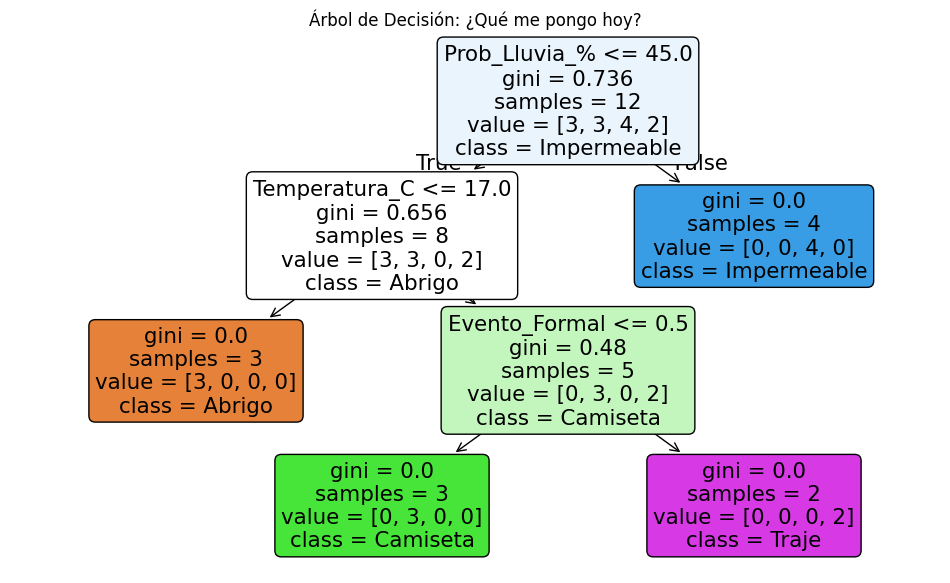


--- SUGERENCIA DEL ALGORITMO PARA HOY ---
Condiciones: 15°C | 90% Lluvia | Evento Casual
Debes ponerte: ¡IMPERMEABLE!


In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Base de datos de nuestros "días pasados" y lo que decidimos ponernos
# Evento_Formal: 1 (Sí, reunión/trabajo), 0 (No, salida casual/casa)
datos_ropa = {
    'Temperatura_C': [30, 12, 18, 25, 10, 32, 14, 22, 8, 28, 24, 20],
    'Prob_Lluvia_%': [10, 20, 80, 10, 30, 5,  90, 5,  10, 70, 5,  60],
    'Evento_Formal': [0,  0,  0,  1,  1,  1,  1,  0,  0,  0,  0,  1 ],
    'Atuendo': [
        'Camiseta',    # Día caluroso, sin lluvia, casual
        'Abrigo',      # Día frío, sin lluvia, casual
        'Impermeable', # Lluvia fuerte, casual
        'Traje',       # Clima agradable, evento formal
        'Abrigo',      # Día frío, formal (el frío gana)
        'Traje',       # Día caluroso, evento formal
        'Impermeable', # Lluvia, evento formal
        'Camiseta',    # Clima agradable, sin lluvia, casual
        'Abrigo',      # Mucho frío, casual
        'Impermeable', # Lluvia, día cálido
        'Camiseta',    # Clima cálido, casual
        'Impermeable'  # Lluvia, evento formal
    ]
}

df = pd.DataFrame(datos_ropa)

# Separamos las características del clima (X) de lo que vamos a predecir (y)
X = df[['Temperatura_C', 'Prob_Lluvia_%', 'Evento_Formal']]
y = df['Atuendo']

# 2. Inicializamos y entrenamos el Árbol de Decisión
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X, y)

# 3. Dibujamos el cerebro del algoritmo
plt.figure(figsize=(12, 7))
plot_tree(modelo,
          feature_names=X.columns,
          class_names=modelo.classes_,
          filled=True,
          rounded=True)
plt.title("Árbol de Decisión: ¿Qué me pongo hoy?")
plt.show()

# 4. Ponemos a prueba el algoritmo con los datos de HOY
# Imagina el clima actual: 15°C, 90% probabilidad de lluvia y es un evento Casual (0)
clima_hoy = pd.DataFrame([[15, 90, 0]], columns=['Temperatura_C', 'Prob_Lluvia_%', 'Evento_Formal'])

prediccion = modelo.predict(clima_hoy)

print("\n--- SUGERENCIA DEL ALGORITMO PARA HOY ---")
print("Condiciones: 15°C | 90% Lluvia | Evento Casual")
print(f"Debes ponerte: ¡{prediccion[0].upper()}!")

El árbol de decisión funciona como un juego de "Adivina quién", donde el algoritmo hace preguntas lógicas de "Sí o No" para ir descartando opciones de ropa hasta llegar a la prenda ideal. En este caso, el modelo evalúa tres factores cotidianos: la temperatura en grados centígrados, la probabilidad de lluvia y si el compromiso es formal o casual.

Así es como el algoritmo razona paso a paso para tomar la decisión:

1. **La variable más importante (La Raíz):** Al analizar el historial de tus días pasados, el algoritmo descubre matemáticamente que la lluvia es el factor más drástico. La primera pregunta interna que se hace es: *¿La probabilidad de lluvia es mayor al 55%?* Si la respuesta es afirmativa, el algoritmo toma un atajo y dictamina que debes usar el **Impermeable**, ignorando por completo el frío o el calor.
2. **La segunda condición (Las Ramas):** Si determina que no hay riesgo de lluvia, el algoritmo necesita seguir buscando. Pasa al segundo factor con mayor peso: el clima. Su pregunta ahora es: *¿La temperatura es muy baja (ej. menor a 13°C)?* Si la respuesta es sí, deduce que hace frío y detiene el camino recomendando el **Abrigo**.
3. **El filtro final (Las Hojas):** Si no llueve y el día es cálido, el algoritmo usa tu última variable para desempatar. Pregunta: *¿El evento es formal?* Si el valor es 1 (Sí), recomienda el **Traje** para la oficina. Si el valor es 0 (No), entiende que es una salida relajada y te sugiere la **Camiseta**.

El verdadero poder de este modelo es que tú nunca le escribiste esas reglas. Al pasarle la tabla de datos inicial, el algoritmo calculó por su cuenta que el 55% de lluvia y los 13°C eran las fronteras matemáticas exactas donde tu decisión de vestuario cambiaba. Básicamente, leyó tu historial y aprendió a imitar la lógica que hace tu cerebro cuando miras por la ventana antes de salir de casa.